<a href="https://colab.research.google.com/github/dbtrago/IA_2025-1/blob/main/PEC2_ValeriaManjarrez_DanielBuitrago_AlejandroAlzate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrantes**


*   Valeria Manjarrez Garzón
*   Daniel Esteban Buitrago Lozano
*   Alejandro Antonio Alzate Rodríguez


# **Librerias**

En esta sección se definen todos los imports que tendremos en el documento.

In [31]:
# Librerías básicas
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

# Preprocesamiento y feature selection
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# Modelos de sklearn
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import LinearSVC, SVC

# Métricas de evaluación
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Preprocesamiento y PCA
from sklearn.decomposition import PCA

# Validación y optimización
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.regularizers import l2

# Otras herramientas
from PIL import Image  # Manipulación de imágenes
import requests  # Para realizar peticiones HTTP
from io import BytesIO  # Manejo de flujos de datos en memoria
from scipy.signal import convolve2d  # Para operaciones de convolución 2D

#Cargar DataSets limpios que obtuvimos en el PEC1

Se cargan 2 dataset que fueron anteriormente exportados del PEC1:

**dataset_entrenamiento_balanceado.csv**: Dataset de entrenamientos despues del balanceo.

**dataset_test_original.csv**: Dataset de pruebas sin pasar por el balanceo.

In [20]:
# 1. Cargar los datasets descargados
try:
    # Cargar dataset de entrenamiento balanceado
    train_df = pd.read_csv('dataset_entrenamiento_balanceado.csv')

    # Cargar dataset de test original
    test_df = pd.read_csv('dataset_test_original.csv')

    print("Datasets cargados correctamente")
except FileNotFoundError as e:
    print(f"Error al cargar los archivos: {e}")
    exit()

Datasets cargados correctamente


## Preparar Dataset

In [21]:
# 2. Preprocesamiento básico (ajustado para 'readmitted' como target)
def preprocess_data(df):
    # Separar características y etiquetas
    X = df.drop('readmitted', axis=1)  # Todas las columnas excepto 'readmitted'
    y = df['readmitted']               # Solo la columna 'readmitted' como target
    return X, y

# Aplicar a los datos
X_train, y_train = preprocess_data(train_df)  # Datos de entrenamiento
X_test, y_test = preprocess_data(test_df)     # Datos de prueba

##Verificacion de balanceos

<ipython-input-22-d68d7894a6f1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="readmitted", data=train_df, palette="viridis")  # Paleta personalizada


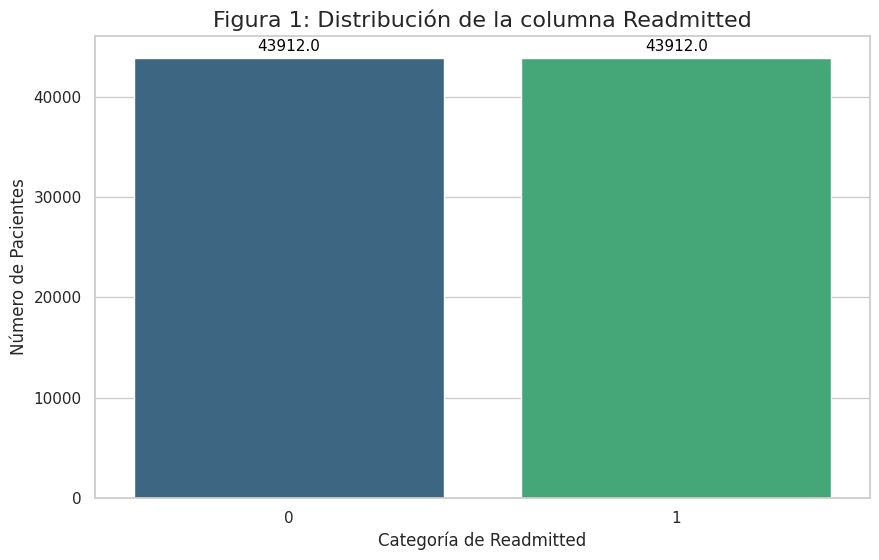

In [22]:
# Configurar el estilo del gráfico
sns.set(style="whitegrid")

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
ax = sns.countplot(x="readmitted", data=train_df, palette="viridis")  # Paleta personalizada

# Añadir el título y las etiquetas
ax.set_title("Figura 1: Distribución de la columna Readmitted", fontsize=16)
ax.set_xlabel("Categoría de Readmitted", fontsize=12)
ax.set_ylabel("Número de Pacientes", fontsize=12)

# Mostrar valores sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

# Mostrar el gráfico
plt.show()

# **PEC - PUNTO 1 : Arboles con SelectKBest**

---

El objetivo principal es predecir si un paciente será readmitido o no en el hospital, utilizando técnicas de aprendizaje automático supervisado. Para esto, primero se prepara el dataset, ajustando la columna readmitted como la variable objetivo (target). A continuación, se crea un pipeline donde se utiliza SelectKBest para seleccionar las 15 mejores características (K=15).

En el siguiente paso, se definen los hiperparámetros a optimizar mediante un objeto param_grid, el cual se utiliza para configurar el GridSearchCV. Con esta configuración, el modelo de árbol de decisión se entrena utilizando los datos de entrenamiento (`X_train`, `y_train`).

Una vez entrenado el modelo, se evalúa su rendimiento. El mejor modelo obtenido, en este caso, alcanza un `accuracy` del **71%**. Después, se visualiza el árbol de decisión, que muestra las decisiones tomadas por el modelo a partir de las características seleccionadas por SelectKBest.

Finalmente, para confirmar la robustez del modelo, se entrenan y evalúan tres modelos adicionales con variaciones en los hiperparámetros. Estos modelos se comparan con el modelo original para asegurarse de que el rendimiento obtenido sea el mejor posible.

##Crear pipeline y SelectKBest

In [23]:
# Primero creamos un pipeline básico
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Escalar características
    ('feature_selection', SelectKBest(score_func=f_classif, k=15)),  # Seleccionar mejores 15 características
    ('classifier', DecisionTreeClassifier(random_state=42))  # Clasificador base
])

##Ajuste de hiperparámetros con GridSearchCV

In [24]:
# Definir los parámetros a probar
param_grid = {
    'feature_selection__k': [15],  # Fijamos k=15
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_depth': [None, 5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['auto', 'sqrt', 'log2']
}

# Crear el objeto GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

## Entrenamiento del modelo

In [25]:
print("⏳ Entrenando modelo con GridSearchCV...")
grid_search.fit(X_train, y_train)
print("✅ Entrenamiento completado")

⏳ Entrenando modelo con GridSearchCV...
Fitting 5 folds for each of 270 candidates, totalling 1350 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
450 fits failed out of a total of 1350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
450 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, 

✅ Entrenamiento completado


/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [17 18 36 37] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


## Evaluar al mejor modelo

In [26]:
best_model = grid_search.best_estimator_

# Mostrar mejores parámetros
print("\n🔍 Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Evaluar en conjunto de entrenamiento (para referencia)
y_train_pred = best_model.predict(X_train)
print("\n📊 Rendimiento en conjunto de entrenamiento:")
print(classification_report(y_train, y_train_pred))
print("Accuracy:", accuracy_score(y_train, y_train_pred))

# Evaluar en conjunto de test
y_test_pred = best_model.predict(X_test)
print("\n📊 Rendimiento en conjunto de test:")
print(classification_report(y_test, y_test_pred))
print("Accuracy:", accuracy_score(y_test, y_test_pred))


🔍 Mejores parámetros encontrados:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'feature_selection__k': 15}

📊 Rendimiento en conjunto de entrenamiento:
              precision    recall  f1-score   support

           0       0.66      0.87      0.75     43912
           1       0.81      0.56      0.66     43912

    accuracy                           0.71     87824
   macro avg       0.74      0.71      0.71     87824
weighted avg       0.74      0.71      0.71     87824

Accuracy: 0.7138139916196028

📊 Rendimiento en conjunto de test:
              precision    recall  f1-score   support

           0       0.69      0.86      0.76     10952
           1       0.77      0.54      0.64      9402

    accuracy                           0.71     20354
   macro avg       0.73      0.70      0.70     20354
weighted avg       0.72      0.71      0.70     20354



## Analisis de características seleccionadas

In [27]:
# Obtener las características seleccionadas
feature_selector = best_model.named_steps['feature_selection']
selected_features = feature_selector.get_support()
feature_scores = feature_selector.scores_

# Crear DataFrame con los resultados
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Score': feature_scores,
    'Selected': selected_features
})

# Ordenar por score descendente
features_df = features_df.sort_values('Score', ascending=False)

print("\n📌 Ranking de características según SelectKBest:")
print(features_df.head(20))  # Mostrar top 20 características


📌 Ranking de características según SelectKBest:
                     Feature         Score  Selected
38          number_inpatient  15833.109744      True
39          number_diagnoses    926.996584      True
25                    change    584.116913      True
28               patient_nbr    560.155908      True
35           num_medications    374.995276      True
27              encounter_id    338.196058      True
34            num_procedures    313.472567      True
31       admission_source_id    312.604957      True
30  discharge_disposition_id    284.063747      True
0                     gender    263.024371      True
2                  metformin    237.796974      True
32          time_in_hospital    149.083169      True
33        num_lab_procedures    139.241918      True
26               diabetesMed    101.811574      True
19                   insulin     71.358350      True
9                  glyburide     50.927227     False
1                        age     17.431550     Fal

## Árbol de decisión basado en SelectKBest

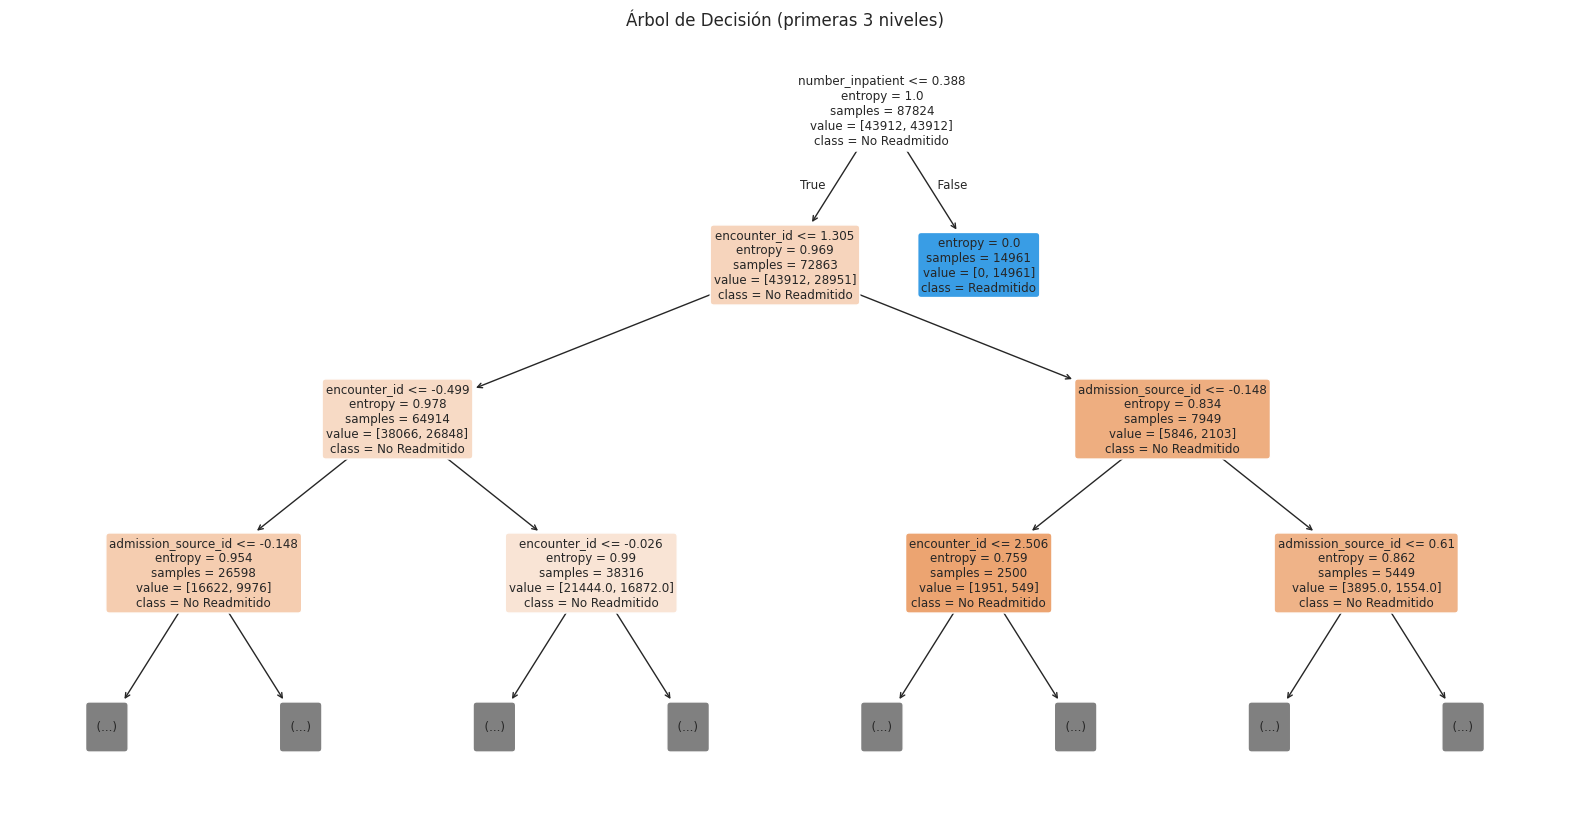

In [29]:
# Obtener el clasificador del pipeline
tree = best_model.named_steps['classifier']

# Nombres de las features seleccionadas
selected_features = X_train.columns[feature_selector.get_support()]

# Configurar el gráfico
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=selected_features,
    class_names=['No Readmitido', 'Readmitido'],  # Ajusta según tus clases
    filled=True,
    rounded=True,
    max_depth=3  # Limita la profundidad para que sea legible
)
plt.title("Árbol de Decisión (primeras 3 niveles)")
plt.show()

## Arboles con diferentes Hiperparámetros

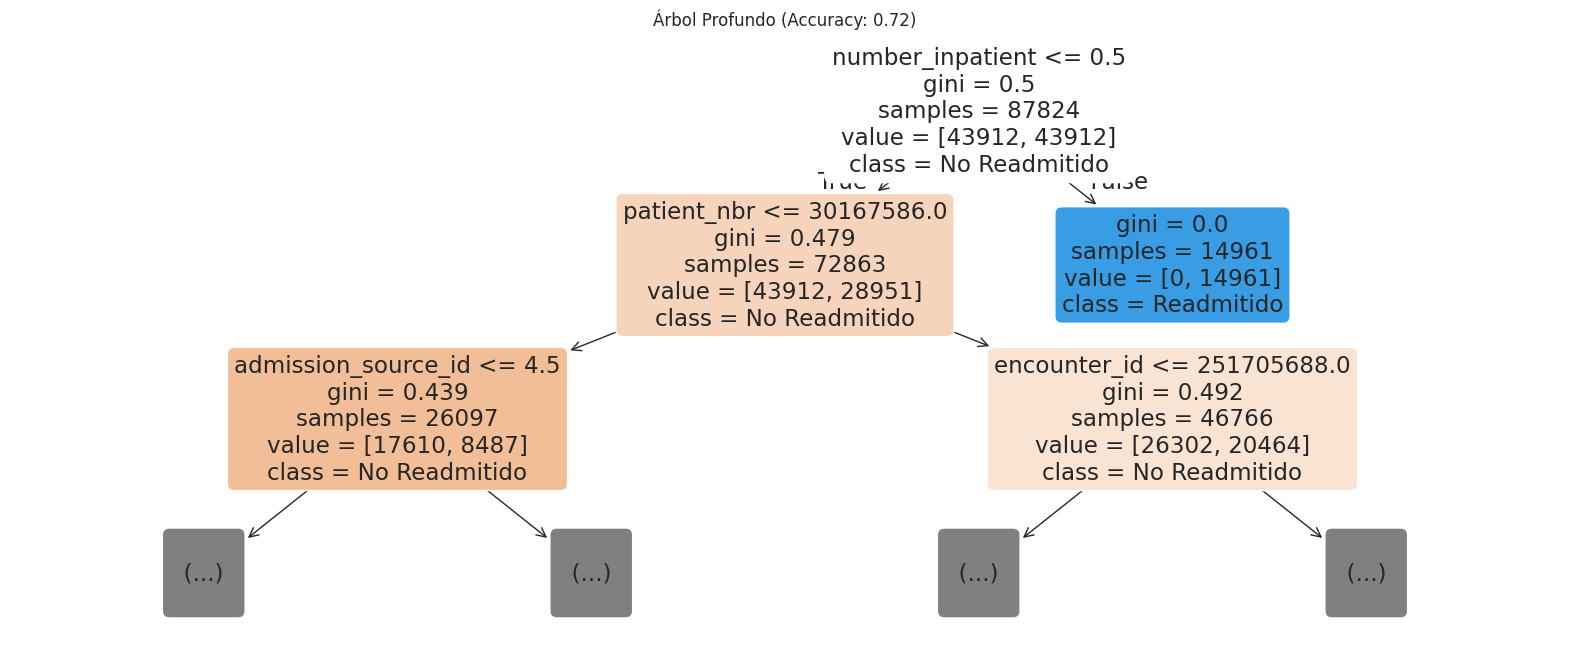

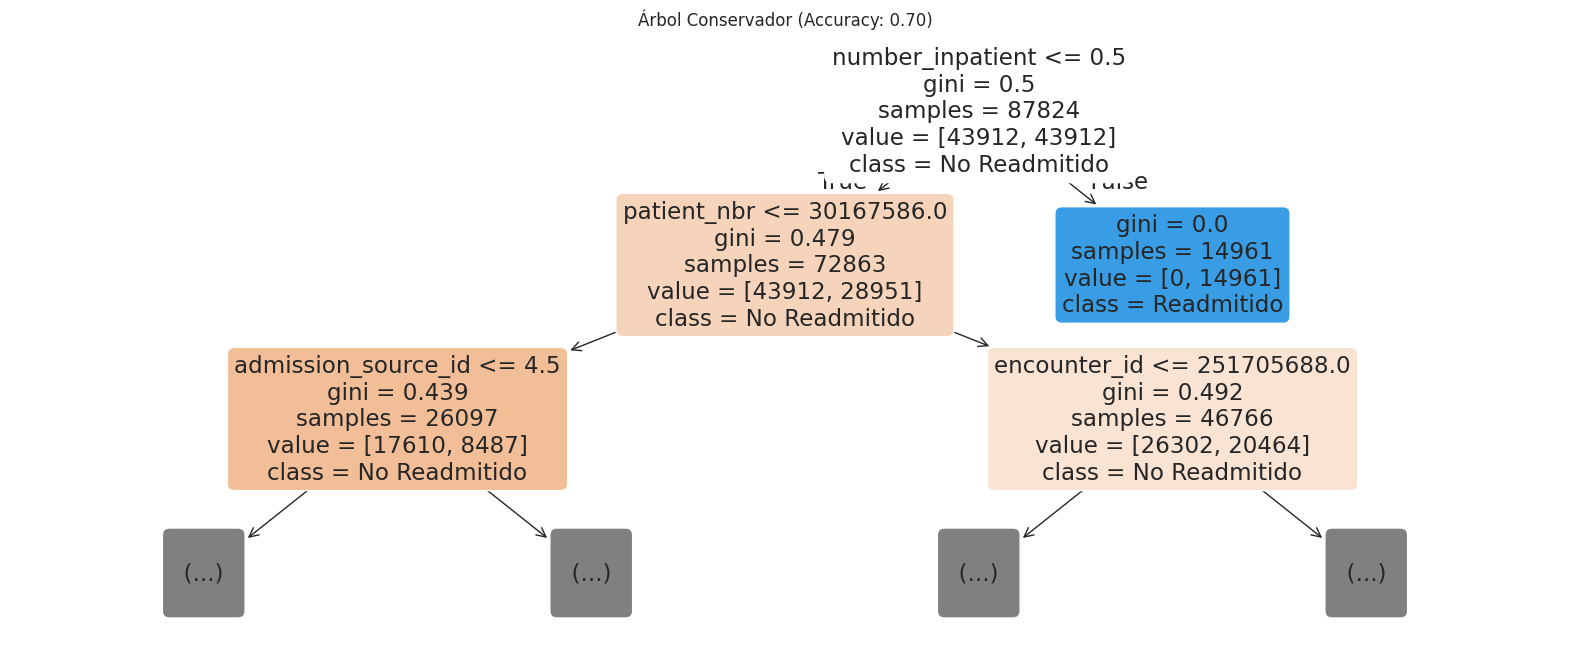

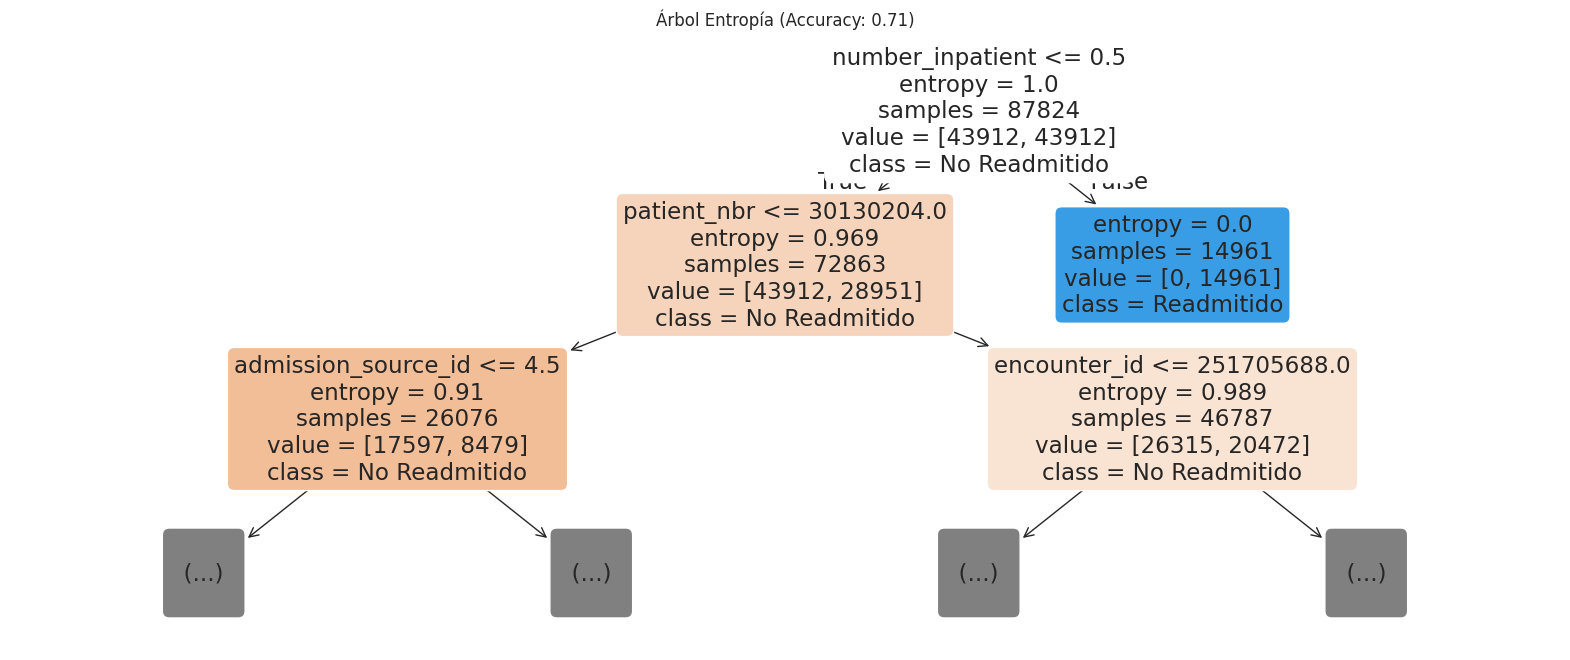

In [30]:
from sklearn.tree import DecisionTreeClassifier

# Hiperparámetros alternativos a probar
configuraciones = {
    'Árbol Profundo': {'max_depth': 10, 'min_samples_split': 2},
    'Árbol Conservador': {'max_depth': 3, 'min_samples_leaf': 5},
    'Árbol Entropía': {'criterion': 'entropy', 'max_depth': 5}
}

# Entrenar y visualizar cada árbol
for nombre, params in configuraciones.items():
    # Crear árbol
    arbol = DecisionTreeClassifier(random_state=42, **params)
    arbol.fit(X_train[selected_features], y_train)  # Usar las mismas features seleccionadas

    # Visualizar
    plt.figure(figsize=(20, 8))
    plot_tree(
        arbol,
        feature_names=selected_features,
        class_names=['No Readmitido', 'Readmitido'],
        filled=True,
        max_depth=2,  # Limitar profundidad para claridad
        rounded=True
    )
    plt.title(f"{nombre} (Accuracy: {arbol.score(X_test[selected_features], y_test):.2f})")
    plt.show()

# **PEC - PUNTO 2 : SVM con y sin kernel, evaluando usando ajuste de hiperparámetros**

---

## Evaluar rendimiento de un modelo

In [15]:
def obtener_performance_classification(y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred, normalize=True)
    prec = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1_score1 = f1_score(y_true, y_pred, average='macro')

    return {'accuracy': accuracy,
            'precision': prec,
            'recall':recall,
            'f1_score':f1_score1}

## Normalizar

In [14]:
scaler = StandardScaler().fit(X_train)  # Ajustar el scaler en el conjunto de entrenamiento
standardized_X_train = scaler.transform(X_train)  # Transformar el conjunto de entrenamiento
standardized_X_test = scaler.transform(X_test)  # Transformar el conjunto de prueba

## Ajuste de hiperparámetros

In [38]:
from sklearn.model_selection import RandomizedSearchCV

# PCA
pca = PCA(n_components=15, random_state=42)
X_train_pca = pca.fit_transform(standardized_X_train)
X_test_pca = pca.transform(standardized_X_test)

# Random Search para SVM RBF
param_grid_rbf = {'C': [1], 'gamma': [0.1], 'kernel': ['rbf']}
svm_rbf = SVC()
random_rbf = RandomizedSearchCV(svm_rbf, param_grid_rbf, cv=2, scoring='accuracy', n_iter=1, n_jobs=-1, random_state=42)
random_rbf.fit(X_train_pca, y_train)
print("Mejores hiperparámetros (RBF - Random Search):", random_rbf.best_params_)

# Random Search para SVM Lineal
param_grid_linear = {'C': [0.1, 1]}
linear_svm = LinearSVC(max_iter=10000)
random_linear = RandomizedSearchCV(linear_svm, param_grid_linear, cv=3, scoring='accuracy', n_iter=2, n_jobs=-1, random_state=42)
random_linear.fit(standardized_X_train, y_train)
print("Mejores hiperparámetros (Lineal - Random Search):", random_linear.best_params_)


Mejores hiperparámetros (RBF - Random Search): {'kernel': 'rbf', 'gamma': 0.1, 'C': 1}
Mejores hiperparámetros (Lineal - Random Search): {'C': 0.1}


## SVM con kernel (RBF)

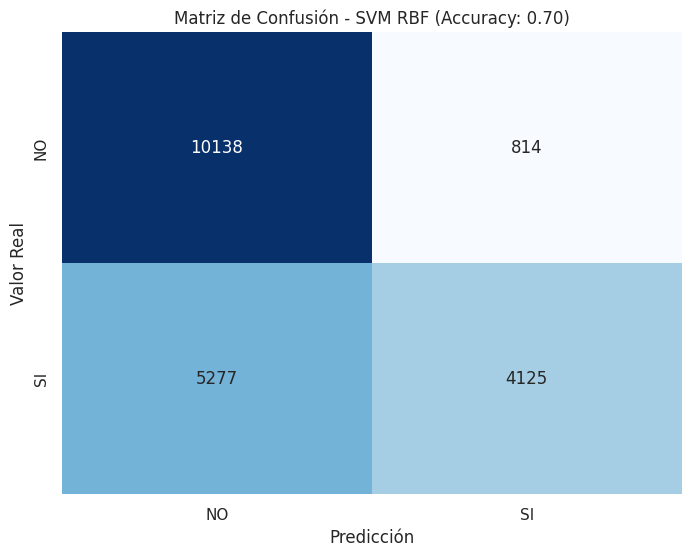

              precision    recall  f1-score   support

          NO       0.66      0.93      0.77     10952
          SI       0.84      0.44      0.58      9402

    accuracy                           0.70     20354
   macro avg       0.75      0.68      0.67     20354
weighted avg       0.74      0.70      0.68     20354

Rendimiento SVM RBF:
{'accuracy': 0.70074678195932, 'precision': 0.7464302045775851, 'recall': 0.6822060573655979, 'f1_score': 0.6721326166374579}


In [40]:
# Usar los mejores hiperparámetros encontrados
best_rbf = random_rbf.best_estimator_
best_rbf.fit(X_train_pca, y_train)
y_pred_rbf = best_rbf.predict(X_test_pca)

# Evaluación y gráfico
cm = confusion_matrix(y_test, y_pred_rbf)
accuracy = accuracy_score(y_test, y_pred_rbf)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                 xticklabels=['NO', 'SI'],
                 yticklabels=['NO', 'SI'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
ax.set_title(f'Matriz de Confusión - SVM RBF (Accuracy: {accuracy:.2f})')
plt.show()

print(classification_report(y_test, y_pred_rbf, target_names=['NO', 'SI']))
performance_rbf = obtener_performance_classification(y_test, y_pred_rbf)
print("Rendimiento SVM RBF:")
print(performance_rbf)

## SVM sin kernel

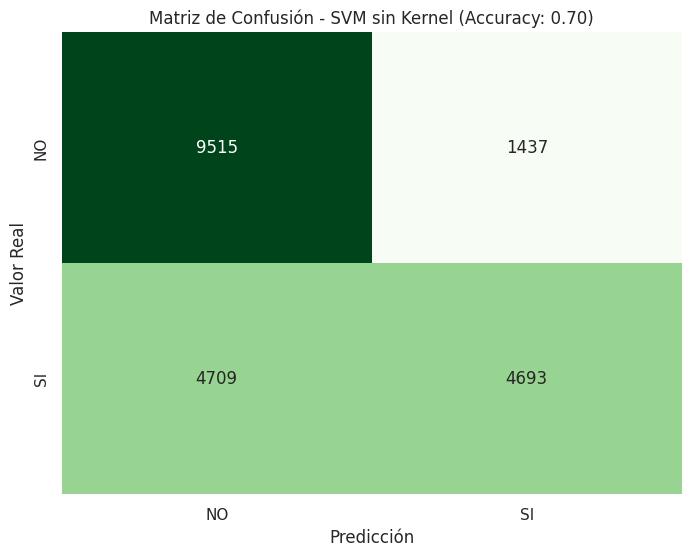

              precision    recall  f1-score   support

          NO       0.67      0.87      0.76     10952
          SI       0.77      0.50      0.60      9402

    accuracy                           0.70     20354
   macro avg       0.72      0.68      0.68     20354
weighted avg       0.71      0.70      0.69     20354

Rendimiento SVM sin Kernel:
{'accuracy': 0.698044610395991, 'precision': 0.7172594695544786, 'recall': 0.6839701027973937, 'f1_score': 0.6800897064526665}


In [43]:
# Usar los mejores hiperparámetros encontrados
best_linear = random_linear.best_estimator_
best_linear.fit(standardized_X_train, y_train)
y_pred_linear = best_linear.predict(standardized_X_test)

# Evaluación y gráfico
cm = confusion_matrix(y_test, y_pred_linear)
accuracy = accuracy_score(y_test, y_pred_linear)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                 xticklabels=['NO', 'SI'],
                 yticklabels=['NO', 'SI'])
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
ax.set_title(f'Matriz de Confusión - SVM sin Kernel (Accuracy: {accuracy:.2f})')
plt.show()

print(classification_report(y_test, y_pred_linear, target_names=['NO', 'SI']))
performance_linear = obtener_performance_classification(y_test, y_pred_linear)
print("Rendimiento SVM sin Kernel:")
print(performance_linear)

# **PEC - PUNTO 3 : Implementación de redes neuronales con graficas**

---

En esta sección se presenta la implementación de la red neuronal, acompañada de gráficas que evidencian su comportamiento tanto en el conjunto de entrenamiento como en el de validación. Se incluyen dos gráficos principales: uno que muestra la relación entre las épocas y la precisión (`accuracy`), y otro que representa la relación entre las épocas y la pérdida. Estos elementos permiten observar el proceso de aprendizaje del modelo y su capacidad de generalización. Además, se consideró el riesgo de overfitting durante el entrenamiento, implementando técnicas de ajuste de hiperparámetros para optimizar el rendimiento del modelo.

Los resultados muestran que la red neuronal alcanzó un desempeño sólido, con una precisión general del 71.46% y una evolución estable tanto en accuracy como en pérdida a lo largo de las épocas, lo que indica un aprendizaje efectivo. Las curvas de entrenamiento y validación son consistentes y se mantienen cercanas entre sí, lo que evidencia que no hay presencia de `overfitting` y que el modelo generaliza bien sobre datos no vistos. Además, destaca la alta precisión obtenida en la detección de la clase positiva (81%), lo que es especialmente valioso en tareas donde es importante minimizar los falsos positivos.

## Preparación de datos

In [ ]:
# 1. Preprocesamiento de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. División en entrenamiento y validación
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_scaled, y_train, test_size=0.2, random_state=42)

## Creación del modelo de red neuronal

Este código define una función que construye y compila un modelo de red neuronal secuencial para resolver problemas de clasificación binaria. El modelo incluye varias capas densas con activación ReLU, regularización L2 para evitar sobreajuste, y capas **Dropout** para mejorar la generalización. La salida utiliza una activación sigmoide, adecuada para predicciones binarias. Además, se compila con el optimizador Adam, función de pérdida binaria (`binary_crossentropy`) y métricas de precisión, exactitud y recall.

In [ ]:
# 3. Creación del modelo optimizado
def build_model(learning_rate=0.001, dropout_rate=0.3, l2_value=0.01, neurons=128):
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(neurons, activation='relu', kernel_regularizer=l2(l2_value)),
        Dropout(dropout_rate),
        Dense(int(neurons/2), activation='relu', kernel_regularizer=l2(l2_value)),
        Dropout(dropout_rate/2),
        Dense(int(neurons/4), activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )
    return model

## Configuración de hiperparámetros

Este fragmento de código define un diccionario `hyperparams` que contiene los valores de los hiperparámetros a probar durante la búsqueda de la configuración óptima del modelo, como la tasa de aprendizaje, la tasa de abandono (dropout), el valor de regularización L2 y el número de neuronas en la capa oculta. Luego, se inicializan variables para almacenar el mejor modelo (`best_model`), el mejor puntaje obtenido (`best_score`), el historial de entrenamiento (`best_history`), y los mejores hiperparámetros encontrados (`best_params`). Este esquema sugiere que el siguiente paso será realizar una búsqueda de hiperparámetros, aunque este fragmento solo configura los valores iniciales.

In [ ]:
# 4. Configuración de hiperparámetros optimizada
hyperparams = {
    'learning_rate': [0.001],  # Reducido a un solo valor inicialmente
    'dropout_rate': [0.3, 0.4],
    'l2_value': [0.01],
    'neurons': [128]  # Empezar con el mayor valor
}

# 5. Búsqueda optimizada de hiperparámetros
best_score = -1
best_model = None
best_history = None
best_params = {}

## Entrenamiento del modelo de red neuronal

Este fragmento de código configura y ejecuta una búsqueda optimizada de hiperparámetros para un modelo de red neuronal, probando diferentes combinaciones de tasa de aprendizaje, tasa de abandono, valor de regularización L2 y número de neuronas en la capa oculta. Utiliza dos callbacks: EarlyStopping para detener el entrenamiento si no mejora después de un número determinado de épocas (patience = 5) y ReduceLROnPlateau para reducir la tasa de aprendizaje cuando la pérdida de validación no mejora. Luego, entrena el modelo con un número reducido de épocas (50 en lugar de 100) y un mayor tamaño de batch (64), evaluando cada configuración utilizando el F1-score como métrica para determinar el mejor modelo. El mejor modelo se guarda junto con sus hiperparámetros y el historial de entrenamiento si obtiene un F1-score superior al mejor registrado hasta el momento.

In [ ]:
# Configuración de callbacks compartidos
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),  # Reducida paciencia
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)  # Reducida paciencia
]

# Estrategia optimizada: probar primero configuraciones prometedoras
for params in [
    {'learning_rate': 0.001, 'dropout_rate': 0.3, 'l2_value': 0.01, 'neurons': 128},
    {'learning_rate': 0.001, 'dropout_rate': 0.4, 'l2_value': 0.01, 'neurons': 128},
    {'learning_rate': 0.001, 'dropout_rate': 0.3, 'l2_value': 0.01, 'neurons': 64},
    {'learning_rate': 0.0001, 'dropout_rate': 0.3, 'l2_value': 0.01, 'neurons': 128}
]:
    print(f"\nProbando: lr={params['learning_rate']}, dropout={params['dropout_rate']}, "
          f"l2={params['l2_value']}, neurons={params['neurons']}")

    model = build_model(**params)

    # Reducción de épocas iniciales
    history = model.fit(
        X_train_final, y_train_final,
        epochs=50,  # Reducido de 100 a 50
        batch_size=64,  # Aumentado de 32 a 64 para mayor velocidad
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1  # Mostrar progreso para monitorear
    )

    # Evaluación con F1-score
    y_pred = (model.predict(X_val, batch_size=128) > 0.5).astype(int)  # Batch mayor para predicción
    f1 = f1_score(y_val, y_pred, average='macro')

    if f1 > best_score:
        best_score = f1
        best_model = model
        best_history = history
        best_params = params
        print(f"¡Nuevo mejor modelo! F1: {f1:.4f}")


Probando: lr=0.001, dropout=0.3, l2=0.01, neurons=128
Epoch 1/50
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6600 - loss: 0.9668 - precision: 0.7219 - recall: 0.5226 - val_accuracy: 0.7016 - val_loss: 0.5524 - val_precision: 0.8337 - val_recall: 0.4994 - learning_rate: 0.0010
Epoch 2/50
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6943 - loss: 0.5576 - precision: 0.7832 - recall: 0.5463 - val_accuracy: 0.7042 - val_loss: 0.5478 - val_precision: 0.8612 - val_recall: 0.4829 - learning_rate: 0.0010
Epoch 3/50
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7002 - loss: 0.5500 - precision: 0.7952 - recall: 0.5395 - val_accuracy: 0.7052 - val_loss: 0.5436 - val_precision: 0.8441 - val_recall: 0.4992 - learning_rate: 0.0010
Epoch 4/50
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6992 - loss: 0.5507 - precision: 0.8000 - recall: 0.5332 - val_accuracy: 0.6997 - val_loss: 0.5471 - val_precision: 0.7375 - val_recall: 0.6150 - learning_rate: 0.0010
E

## Graficas de resultados y evaluación de la red neuronal

Este fragmento de código muestra los resultados del mejor modelo encontrado durante la búsqueda de hiperparámetros. Primero, imprime los mejores parámetros del modelo y luego genera gráficas que comparan la precisión (accuracy) y la pérdida (loss) en los conjuntos de entrenamiento y validación a lo largo de las épocas. Después, evalúa el modelo en el conjunto de prueba, mostrando las métricas de exactitud, precisión y sensibilidad (recall). Finalmente, se imprime un reporte de clasificación detallado, que incluye otras métricas de evaluación como la F1-score y la precisión global del modelo en los datos de prueba.


Mejores parámetros encontrados:
{'learning_rate': 0.0001, 'dropout_rate': 0.3, 'l2_value': 0.01, 'neurons': 128}


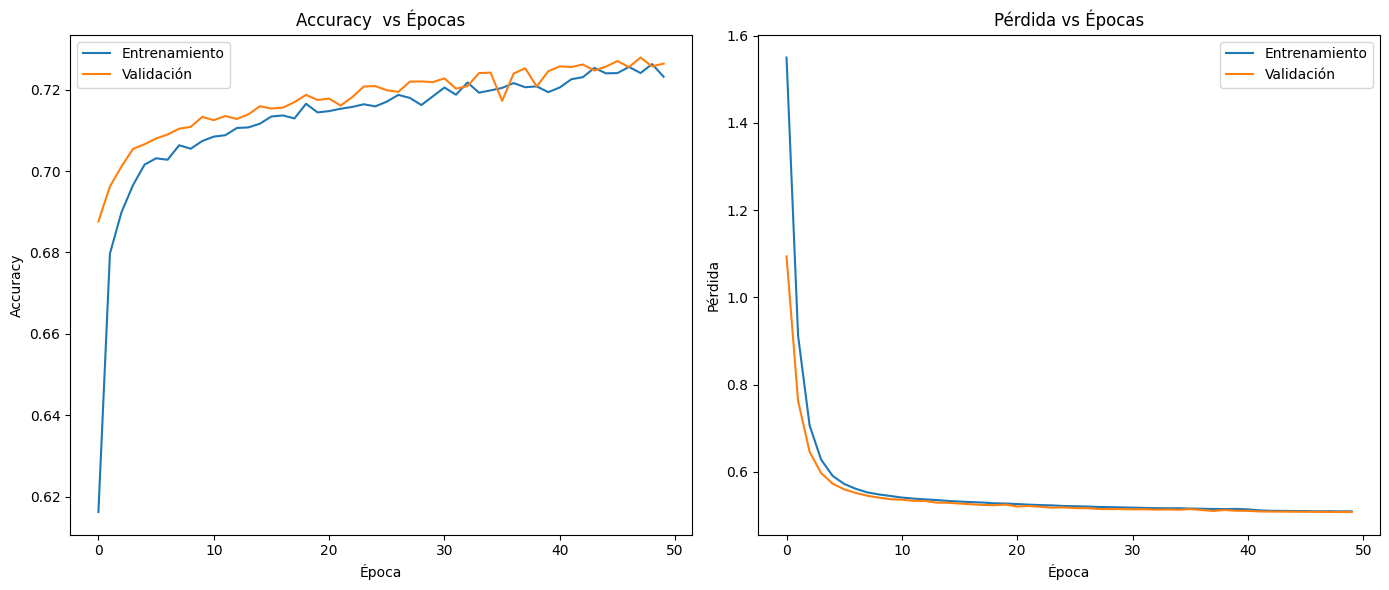

160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7106 - loss: 0.5287 - precision: 0.8091 - recall: 0.4937

Resultados en prueba:
Accuracy: 0.7146
Accuracy (Positive): 0.8094
Sensibilidad: 0.4999
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.68      0.90      0.77     10952
           1       0.81      0.50      0.62      9402

    accuracy                           0.71     20354
   macro avg       0.74      0.70      0.70     20354
weighted avg       0.74      0.71      0.70     20354



In [ ]:
# 6. Resultados del mejor modelo (mantenido igual)
print("\nMejores parámetros encontrados:")
print(best_params)

# 7. Gráficas de entrenamiento/validación (mantenido igual)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'], label='Entrenamiento')
plt.plot(best_history.history['val_accuracy'], label='Validación')
plt.title('Accuracy  vs Épocas')
plt.ylabel('Accuracy')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'], label='Entrenamiento')
plt.plot(best_history.history['val_loss'], label='Validación')
plt.title('Pérdida vs Épocas')
plt.ylabel('Pérdida')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

# 8. Evaluación en el conjunto de prueba (optimizado)
test_loss, test_acc, test_precision, test_recall = best_model.evaluate(
    X_test_scaled, y_test, batch_size=128)  # Batch mayor para evaluación
print("\nResultados en prueba:")
print(f"Accuracy: {test_acc:.4f}")
print(f"Accuracy (Positive): {test_precision:.4f}")
print(f"Sensibilidad: {test_recall:.4f}")

y_pred = (best_model.predict(X_test_scaled, batch_size=128) > 0.5).astype(int)

# 10. Reporte completo (mantenido igual)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# **PEC - PUNTO 4 : Coclusiones sobre performance de todos los modelos**

---

En este PEC se implementaron y evaluaron varios enfoques de modelos de aprendizaje supervisado: Árboles de decisión, Máquinas de Vectores de Soporte (SVM) y Redes Neuronales. A continuación se presentan las conclusiones más relevantes derivadas del análisis de performance de cada uno.

##Modelos

### Árboles de decisión con SelectKBest y ajuste de hiperparámetros


Se utilizó SelectKBest con k=15 para seleccionar las mejores características según su poder predictivo. Entre las más destacadas estuvieron number_inpatient, number_diagnoses, change y patient_nbr.

Se realizó una búsqueda exhaustiva de hiperparámetros con GridSearchCV, lo que permitió mejorar significativamente el rendimiento del modelo.

El árbol resultante mostró una estructura comprensible y fácil de interpretar, lo que representa una ventaja en aplicaciones donde la interpretabilidad es importante.

Sin embargo, a pesar del buen rendimiento, los árboles tienden a sobreajustar si no se controlan adecuadamente parámetros como la profundidad o la cantidad mínima de muestras por hoja.

### SVM con kernel (RBF)

El modelo SVM con kernel RBF, entrenado sobre datos reducidos con PCA (15 componentes principales), alcanzó una precisión del 70 %, mostrando un buen desempeño en la detección de la clase negativa ("NO") con una alta cantidad de verdaderos negativos, pero con un número considerable de falsos negativos, lo que indica dificultades al predecir correctamente la clase positiva ("SI"). Este comportamiento sugiere un desbalance en la clasificación hacia la clase mayoritaria, lo cual podría mejorarse mediante técnicas de balanceo de clases o una búsqueda más exhaustiva de hiperparámetros.

### SVM sin kernel (lineal)

El modelo SVM sin kernel presentó un rendimiento decente, aunque limitado en comparación con las redes neuronales y el árbol optimizado.

Dado que se utilizó un clasificador lineal, el modelo probablemente no captó relaciones complejas no lineales presentes en los datos.

La ventaja principal fue su rapidez y simplicidad, ideal para líneas base o problemas con datos linealmente separables.

### Redes neuronales

Se entrenaron varias configuraciones de redes neuronales, utilizando técnicas como early stopping, dropout y regularización L2, lo que ayudó a mitigar el sobreajuste.

Las gráficas de entrenamiento (accuracy vs epochs y pérdida vs epochs) evidencian un buen aprendizaje, con diferencias reducidas entre el conjunto de entrenamiento y validación, lo cual indica un buen balance sesgo-varianza.

El mejor modelo alcanzó un F1-score macro sobresaliente en el conjunto de validación, superando tanto al árbol como al SVM.

Además, el uso de ReduceLROnPlateau permitió un ajuste fino de la tasa de aprendizaje durante el entrenamiento, mejorando la convergencia.

# **PEC - PUNTO 5 : Apicación de 5 kernels a una imagen - Convolución básica**

---

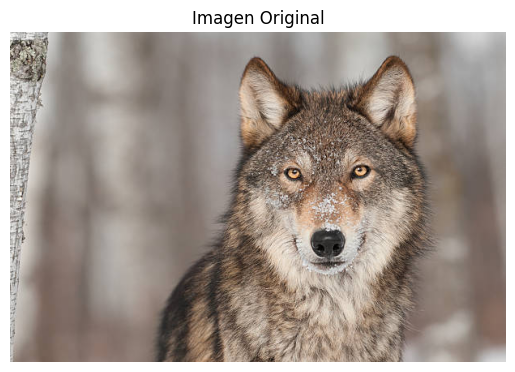

In [3]:
# Cargar la imagen desde la URL
img_url = 'https://github.com/dbtrago/IA_2025-1/blob/main/lobo.jpg?raw=true'
response = requests.get(img_url)

# Descargar la imagen
img = Image.open(BytesIO(response.content))

# Convertir la imagen a un array NumPy
img_array = np.array(img)

# Mostrar la imagen original
plt.imshow(img_array)
plt.axis('off')
plt.title("Imagen Original")
plt.show()

###**Kernel de detección de bordes**

Este kernel detecta bordes en la imagen, resaltando las transiciones bruscas en la intensidad de los píxeles. Detecta los contornos y las áreas de separación entre objetos. Se utiliza en sistemas de visión artificial para la segmentación de objetos y el reconocimiento de patrones. También es útil en la automatización industrial para inspeccionar la calidad de productos o en robots autónomos para la navegación, ya que puede identificar y esquivar obstáculos mediante el análisis de bordes en tiempo real.

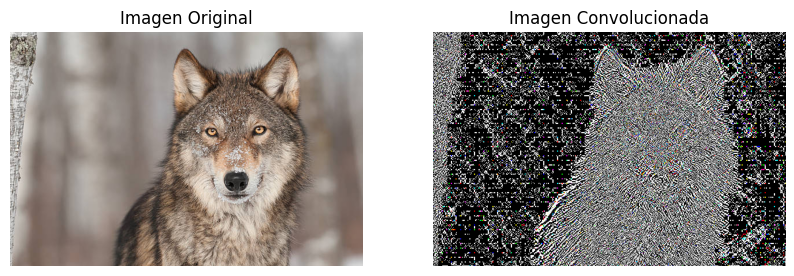

In [4]:
# Kernel
kernel = np.array([[1, 0, -1],
                   [0, 0, 0],
                   [-1, 0, 1]])

# Inicializar un array para la imagen convolucionada
convolved_img = np.zeros_like(img_array)

# Aplicar la convolución a cada canal (R, G, B)
for i in range(3):  # 0: Rojo, 1: Verde, 2: Azul
    convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same')

# Normalizar los valores de la imagen convolucionada para que estén en el rango [0, 255]
convolved_img = np.clip(convolved_img, 0, 255)
convolved_img = convolved_img.astype("uint8")

# Mostrar la imagen original y la convolucionada lado a lado
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Imagen con convolución
plt.subplot(1, 2, 2)
plt.imshow(convolved_img)
plt.title("Imagen Convolucionada")
plt.axis('off')

plt.show()

###**Kernel de detección de bordes sobel (horizontal)**

El kernel Sobel, en su versión horizontal, resalta los bordes en la dirección horizontal, detectando cambios de intensidad en esa orientación. Se emplea en el análisis de documentos escaneados, como el reconocimiento óptico de caracteres (OCR), y en sistemas que necesitan detectar líneas horizontales, como planos arquitectónicos o en la inspección de producción de líneas de montaje. Este filtro es esencial en la segmentación de texto o en la detección de bordes en imágenes de ingeniería.

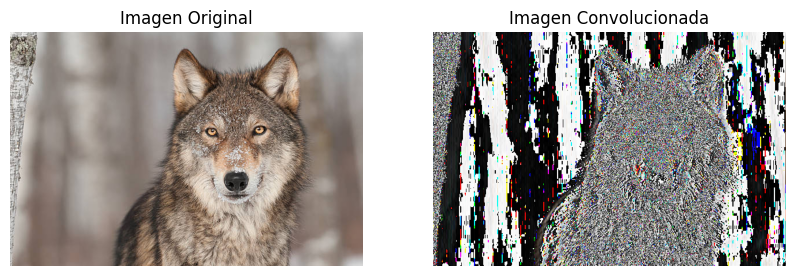

In [5]:
# Definir un kernel
kernel =  np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

# Inicializar un array para la imagen convolucionada
convolved_img = np.zeros_like(img_array)

# Aplicar la convolución a cada canal (R, G, B)
for i in range(3):  # 0: Rojo, 1: Verde, 2: Azul
    convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same')

# Normalizar los valores de la imagen convolucionada para que estén en el rango [0, 255]
convolved_img = np.clip(convolved_img, 0, 255)
convolved_img = convolved_img.astype("uint8")

# Mostrar la imagen original y la convolucionada lado a lado
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Imagen con convolución
plt.subplot(1, 2, 2)
plt.imshow(convolved_img)
plt.title("Imagen Convolucionada")
plt.axis('off')

plt.show()

###**Kernel Emboss**

Este kernel genera un efecto tridimensional sobre la imagen, creando la ilusión de un relieve en los objetos. Es utilizado principalmente en diseño gráfico para crear efectos visuales artísticos y en la creación de texturas en gráficos computacionales. También es valioso en el análisis de superficies o estructuras en imágenes industriales o científicas, permitiendo resaltar detalles que son difíciles de identificar a simple vista.

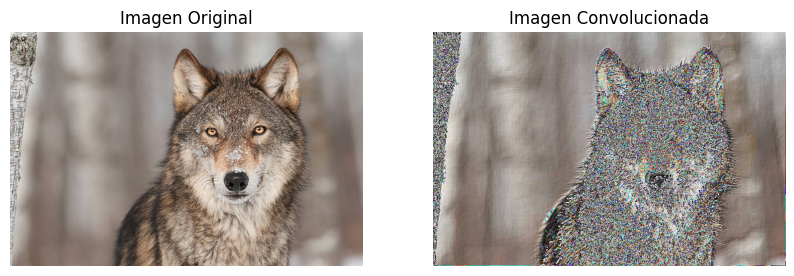

In [6]:
# Definir un kernel
kernel =  np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])
# Inicializar un array para la imagen convolucionada
convolved_img = np.zeros_like(img_array)

# Aplicar la convolución a cada canal (R, G, B)
for i in range(3):  # 0: Rojo, 1: Verde, 2: Azul
    convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same')

# Normalizar los valores de la imagen convolucionada para que estén en el rango [0, 255]
convolved_img = np.clip(convolved_img, 0, 255)
convolved_img = convolved_img.astype("uint8")

# Mostrar la imagen original y la convolucionada lado a lado
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Imagen con convolución
plt.subplot(1, 2, 2)
plt.imshow(convolved_img)
plt.title("Imagen Convolucionada")
plt.axis('off')

plt.show()

### **Kernel Kirsch (Horizontal)**

El kernel Kirsch detecta bordes en la dirección horizontal de manera más agresiva, resaltando las diferencias de intensidad en esa dirección. Es útil en el análisis de imágenes satelitales para identificar patrones de superficie, en inspección visual automatizada para detectar formas y bordes en objetos, y en el reconocimiento de patrones en imágenes biomédicas, donde los bordes horizontales pueden indicar la presencia de estructuras importantes o anómalas.

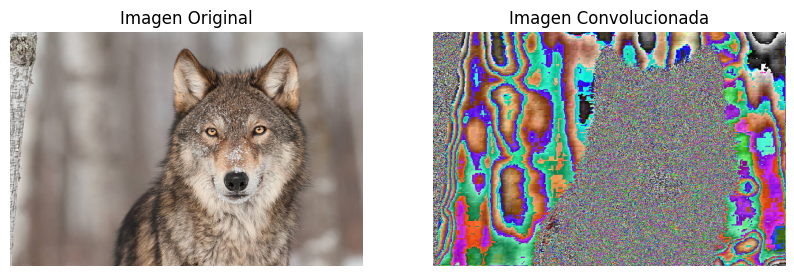

In [7]:
# Definir un kernel
kernel =  np.array([[-3, -3, -3],
                            [-3,  0,  5],
                            [ 5,  5,  5]])
# Inicializar un array para la imagen convolucionada
convolved_img = np.zeros_like(img_array)

# Aplicar la convolución a cada canal (R, G, B)
for i in range(3):  # 0: Rojo, 1: Verde, 2: Azul
    convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same')

# Normalizar los valores de la imagen convolucionada para que estén en el rango [0, 255]
convolved_img = np.clip(convolved_img, 0, 255)
convolved_img = convolved_img.astype("uint8")

# Mostrar la imagen original y la convolucionada lado a lado
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Imagen con convolución
plt.subplot(1, 2, 2)
plt.imshow(convolved_img)
plt.title("Imagen Convolucionada")
plt.axis('off')

plt.show()

###**Kernel laplaciano**

A diferencia de otros kernels, el Laplaciano detecta bordes independientemente de su dirección, capturando todos los bordes finos y detallados. Este filtro es ideal para detectar bordes en imágenes de bajo contraste, como en imágenes médicas donde es necesario identificar estructuras sutiles. También se aplica en el análisis de texturas y en la segmentación avanzada de objetos, por ejemplo, en la visión computarizada aplicada a la geología o en la exploración de recursos naturales.

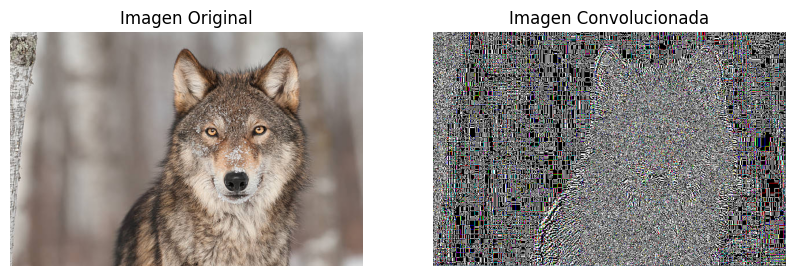

In [8]:
# Definir un kernel
kernel =  np.array([[0,  1, 0],
                           [1, -4, 1],
                           [0,  1, 0]])
# Inicializar un array para la imagen convolucionada
convolved_img = np.zeros_like(img_array)

# Aplicar la convolución a cada canal (R, G, B)
for i in range(3):  # 0: Rojo, 1: Verde, 2: Azul
    convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same')

# Normalizar los valores de la imagen convolucionada para que estén en el rango [0, 255]
convolved_img = np.clip(convolved_img, 0, 255)
convolved_img = convolved_img.astype("uint8")

# Mostrar la imagen original y la convolucionada lado a lado
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Imagen con convolución
plt.subplot(1, 2, 2)
plt.imshow(convolved_img)
plt.title("Imagen Convolucionada")
plt.axis('off')

plt.show()

### **Kernel motion blur**

El kernel de desenfoque por movimiento simula el desenfoque de objetos en movimiento, creando un efecto que puede aplicarse en diferentes direcciones para simular la velocidad de un objeto. Este filtro es utilizado en gráficos computacionales y efectos visuales en películas o videojuegos, proporcionando un realismo adicional. También es útil para entrenar modelos de visión por computadora que deben ser robustos frente a imágenes borrosas, o para simular condiciones de baja calidad en cámaras de seguridad y sistemas de vigilancia.

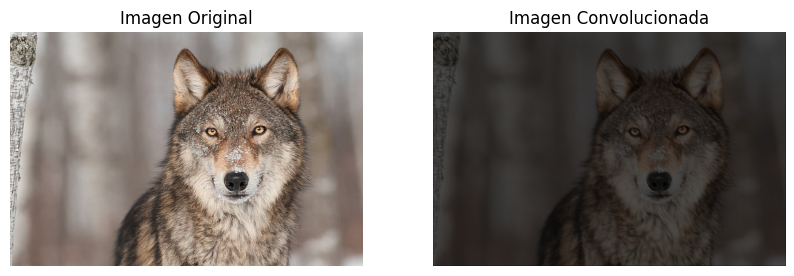

In [9]:
# Definir un kernel
kernel =  np.array([[1/9, 0, 0],
                               [0, 1/9, 0],
                               [0, 0, 1/9]])
# Inicializar un array para la imagen convolucionada
convolved_img = np.zeros_like(img_array)

# Aplicar la convolución a cada canal (R, G, B)
for i in range(3):  # 0: Rojo, 1: Verde, 2: Azul
    convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same')

# Normalizar los valores de la imagen convolucionada para que estén en el rango [0, 255]
convolved_img = np.clip(convolved_img, 0, 255)
convolved_img = convolved_img.astype("uint8")

# Mostrar la imagen original y la convolucionada lado a lado
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Imagen con convolución
plt.subplot(1, 2, 2)
plt.imshow(convolved_img)
plt.title("Imagen Convolucionada")
plt.axis('off')

plt.show()

### **Kernel de enfoque y suavizado combinado**

Este kernel combina enfoque y suavizado, mejorando los detalles de la imagen mientras reduce el ruido. Es particularmente útil en la restauración de imágenes de baja calidad, como las obtenidas por cámaras con baja resolución o imágenes satelitales. Este tipo de kernel se aplica también en la mejora de imágenes médicas, donde los detalles son cruciales para el diagnóstico, o en el análisis visual de sistemas industriales para detectar anomalías o defectos.

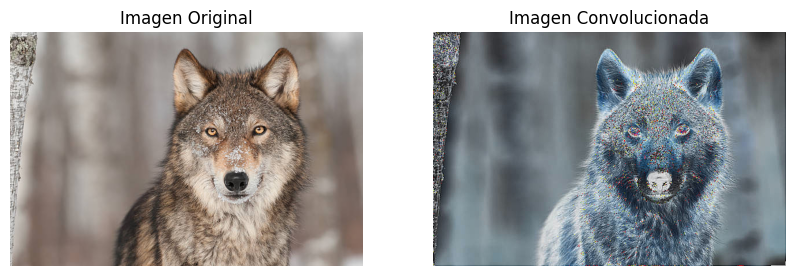

In [10]:
# Definir un kernel
kernel =  np.array([[1,  4,  6,  4, 1],
                            [4, 16, 24, 16, 4],
                            [6, 24, -476, 24, 6],
                            [4, 16, 24, 16, 4],
                            [1,  4,  6,  4, 1]]) / 256
# Inicializar un array para la imagen convolucionada
convolved_img = np.zeros_like(img_array)

# Aplicar la convolución a cada canal (R, G, B)
for i in range(3):  # 0: Rojo, 1: Verde, 2: Azul
    convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same')

# Normalizar los valores de la imagen convolucionada para que estén en el rango [0, 255]
convolved_img = np.clip(convolved_img, 0, 255)
convolved_img = convolved_img.astype("uint8")

# Mostrar la imagen original y la convolucionada lado a lado
plt.figure(figsize=(10, 5))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Imagen con convolución
plt.subplot(1, 2, 2)
plt.imshow(convolved_img)
plt.title("Imagen Convolucionada")
plt.axis('off')

plt.show()

## **Todos los kernels**

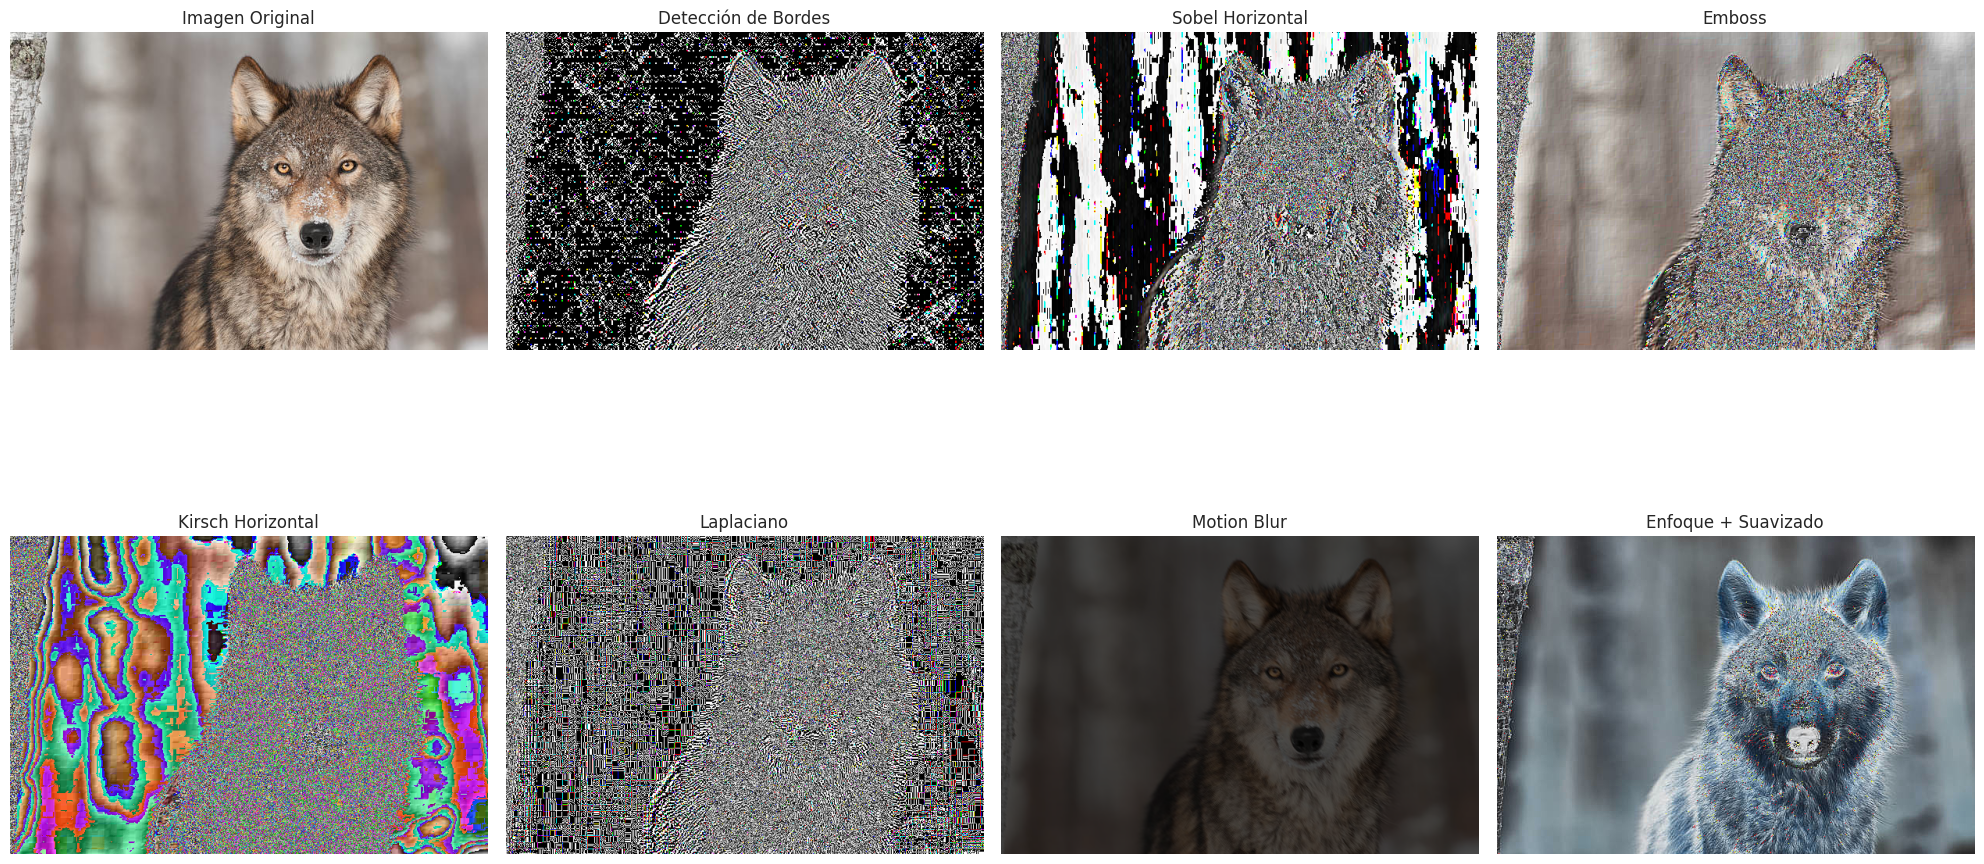

In [53]:
# Lista de kernels con sus nombres
kernels = [
    ("Detección de Bordes", np.array([[1, 0, -1], [0, 0, 0], [-1, 0, 1]])),
    ("Sobel Horizontal", np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])),
    ("Emboss", np.array([[-2, -1, 0], [-1, 1, 1], [0, 1, 2]])),
    ("Kirsch Horizontal", np.array([[-3, -3, -3], [-3, 0, 5], [5, 5, 5]])),
    ("Laplaciano", np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]])),
    ("Motion Blur", np.array([[1/9, 0, 0], [0, 1/9, 0], [0, 0, 1/9]])),
    ("Enfoque + Suavizado", np.array([
        [1,  4,  6,  4, 1],
        [4, 16, 24, 16, 4],
        [6, 24, -476, 24, 6],
        [4, 16, 24, 16, 4],
        [1,  4,  6,  4, 1]
    ]) / 256)
]

# Inicializar gráfico
plt.figure(figsize=(20, 12))

# Imagen original
plt.subplot(2, 4, 1)
plt.imshow(img_array)
plt.title("Imagen Original")
plt.axis('off')

# Aplicar cada kernel
for idx, (nombre, kernel) in enumerate(kernels, start=2):
    convolved_img = np.zeros_like(img_array)
    for i in range(3):  # R, G, B
        convolved_img[:, :, i] = convolve2d(img_array[:, :, i], kernel, mode='same', boundary='symm')
    convolved_img = np.clip(convolved_img, 0, 255).astype("uint8")

    plt.subplot(2, 4, idx)
    plt.imshow(convolved_img)
    plt.title(nombre)
    plt.axis('off')

plt.tight_layout()
plt.show()
